In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/henriqueyamahata/bank-marketing/bank-additional-names.txt
/kaggle/input/datasets/henriqueyamahata/bank-marketing/bank-additional-full.csv


TASK 1: TERM DEPOSIT PREDICTION

Dataset Shape: (41188, 21)

First 5 Rows:
   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1    999         0  nonexisten

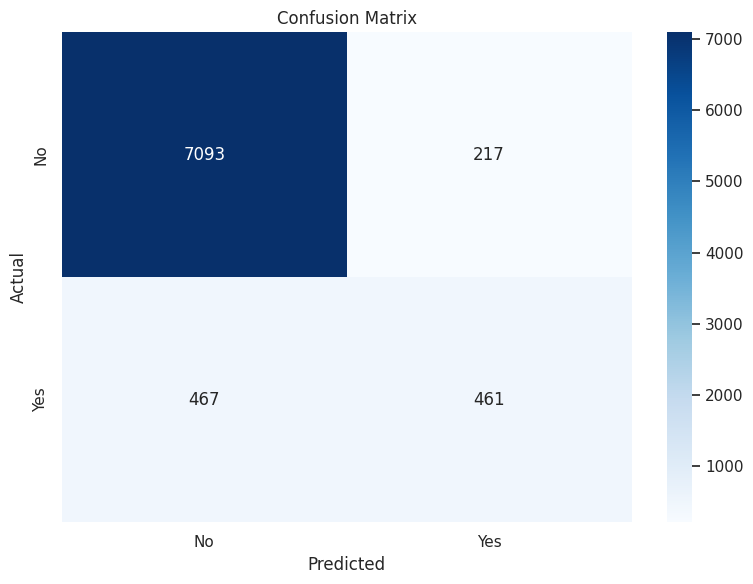

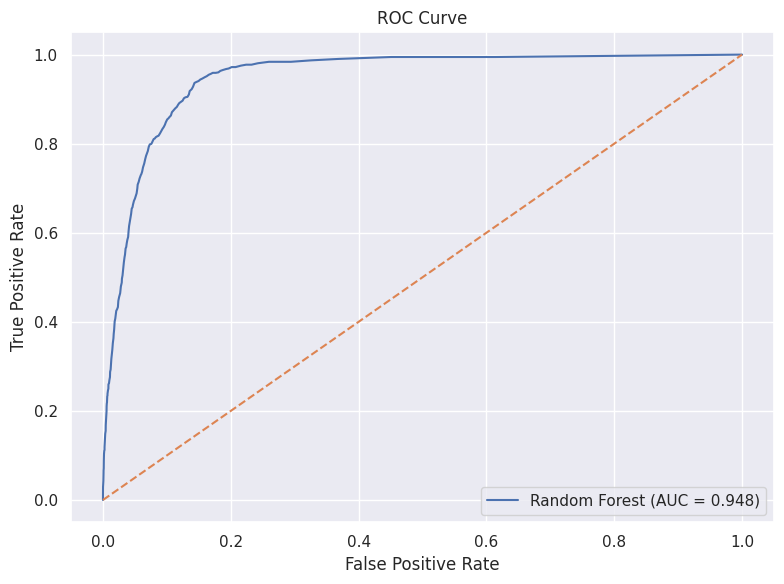

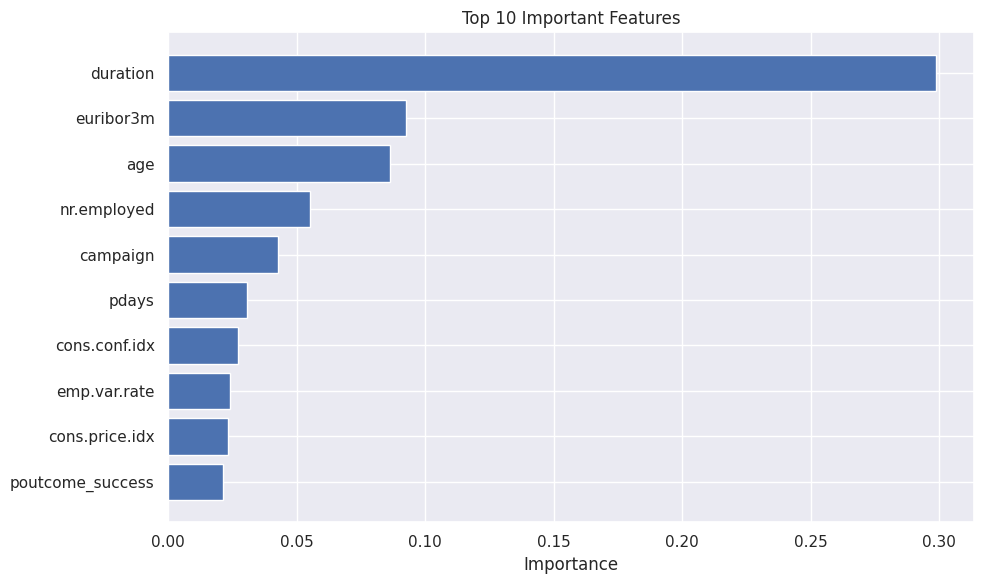


Top 10 Features:
             Feature  Importance
1           duration    0.298529
8          euribor3m    0.092640
0                age    0.086380
9        nr.employed    0.055432
2           campaign    0.042664
3              pdays    0.030869
7      cons.conf.idx    0.027080
5       emp.var.rate    0.024202
6     cons.price.idx    0.023329
52  poutcome_success    0.021348

Calculating SHAP Values...


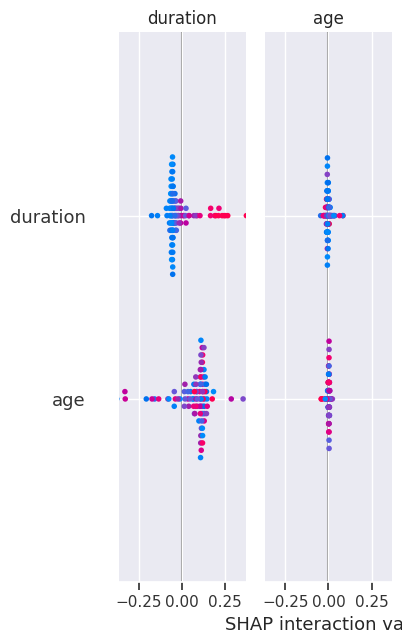


Task Completed Successfully!


In [9]:
# ==========================================
# TASK 1: TERM DEPOSIT SUBSCRIPTION PREDICTION
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

warnings.filterwarnings("ignore")

# -------------------------------
# Visualization Style
# -------------------------------
sns.set_theme(style="darkgrid")

print("=" * 60)
print("TASK 1: TERM DEPOSIT PREDICTION")
print("=" * 60)

# -------------------------------
# Load Dataset
# -------------------------------
df = pd.read_csv(
    "/kaggle/input/datasets/henriqueyamahata/bank-marketing/bank-additional-full.csv",
    sep=";"
)

print("\nDataset Shape:", df.shape)

print("\nFirst 5 Rows:")
print(df.head())

print("\nTarget Distribution:")
print(df["y"].value_counts())

# -------------------------------
# Data Preprocessing
# -------------------------------
print("\nPreprocessing Data...")

categorical_cols = df.select_dtypes(include="object").columns

df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

X = df_encoded.drop("y_yes", axis=1)
y = df_encoded["y_yes"]

print("Feature Matrix Shape:", X.shape)
print("Positive Class Ratio:", round(y.mean(), 3))

# -------------------------------
# Train-Test Split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# -------------------------------
# Train Model
# -------------------------------
print("\nTraining Random Forest...")

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# -------------------------------
# Predictions
# -------------------------------
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

# -------------------------------
# Evaluation
# -------------------------------
auc = roc_auc_score(y_test, y_proba)

print("\nROC-AUC Score:", round(auc, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# -------------------------------
# Confusion Matrix
# -------------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No", "Yes"],
    yticklabels=["No", "Yes"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()

# -------------------------------
# ROC Curve
# -------------------------------
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {auc:.3f})"
)

plt.plot([0, 1], [0, 1], "--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.savefig("roc_curve.png")
plt.show()

# -------------------------------
# Feature Importance
# -------------------------------
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).head(10)

plt.figure(figsize=(10, 6))
plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()

print("\nTop 10 Features:")
print(feature_importance)

# -------------------------------
# SHAP Analysis
# -------------------------------
print("\nCalculating SHAP Values...")

sample_X = X_test.sample(
    min(100, len(X_test)),
    random_state=42
)

explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(sample_X)

# Binary classification compatibility
if isinstance(shap_values, list):
    shap.summary_plot(
        shap_values[1],
        sample_X,
        show=False
    )
else:
    shap.summary_plot(
        shap_values,
        sample_X,
        show=False
    )

plt.tight_layout()
plt.savefig("shap_summary.png")
plt.show()

print("\nTask Completed Successfully!")